# Sprint 5 - Diagnosing the removal failure, then one gated retry

The pilot could not test the hypothesis because the operation fired on 29.4% of MLO images and
**0% of density D**. 24 of 34 rejections were "nothing touching top and left". This notebook
finds out why, fixes it if it is fixable, and only then re-runs the paired test.

**Nothing here touches AUC until the gate passes.** The gate:

| Requirement | Threshold |
|---|---|
| Applied on MLO | >= 80% |
| Applied on density D MLO | >= 80% |
| Left and right handled alike | rates within 10 points |
| Breast tissue and lesions intact | confirmed by eye |
| CC applied rate stays low | far below MLO |

Append these cells to the same session as the pilot, after section A.

In [22]:
REQUIRED = ['load_raw', 'crop_breast', 'remove_pectoral', 'ev', 'work', 'pick']
missing = [n for n in REQUIRED if n not in globals()]
if missing:
    raise SystemExit('Run the pilot notebook through section A first. Missing: ' + ', '.join(missing))

import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt
DIAG_SEED = 7

## 1. Is the failure about density, or about site?

The pilot reported 70% applied on the density-unknown group. Density is missing entirely for
site 2, so "unknown" is "site 2". If the applied rate tracks site rather than density, the
problem is an acquisition convention, not tissue.

In [23]:
diag = work[work.view == 'MLO'].copy()
samp = pd.concat([pick(g, 40) for _, g in diag.groupby(['site_id', diag.laterality])]
                 ).drop_duplicates('image_id').reset_index(drop=True)
print('%d MLO images across site and laterality' % len(samp))

rows = []
for _, r in samp.iterrows():
    raw = load_raw(r['path'])
    _, mask, info = remove_pectoral(raw, return_mask=True)
    rows.append(dict(image_id=r.image_id, site=r.site_id, lat=r.laterality,
                     density=r.density, cancer=r.cancer,
                     h=raw.shape[0], w=raw.shape[1], **info))
d = pd.DataFrame(rows)

print()
print('APPLIED RATE BY SITE')
print(d.groupby('site').applied.agg(['mean', 'size']).round(3).to_string())
print()
print('APPLIED RATE BY LATERALITY')
print(d.groupby('lat').applied.agg(['mean', 'size']).round(3).to_string())
print()
print('APPLIED RATE BY SITE x LATERALITY')
print(d.groupby(['site', 'lat']).applied.agg(['mean', 'size']).round(3).to_string())
print()
print('APPLIED RATE BY DENSITY (site 1 only, where density exists)')
print(d[d.site == 1].groupby(d.density).applied.agg(['mean', 'size']).round(3).to_string())
print()
print('If the split is by site and not by density, the cause is an image convention.')
print('If it is by laterality, the flip logic is choosing the wrong corner.')

160 MLO images across site and laterality

APPLIED RATE BY SITE
       mean  size
site             
1     0.212    80
2     0.650    80

APPLIED RATE BY LATERALITY
      mean  size
lat             
L    0.400    80
R    0.462    80

APPLIED RATE BY SITE x LATERALITY
           mean  size
site lat             
1    L    0.175    40
     R    0.250    40
2    L    0.625    40
     R    0.675    40

APPLIED RATE BY DENSITY (site 1 only, where density exists)
          mean  size
density             
A        0.000     4
B        0.235    34
C        0.179    39
D        1.000     2

If the split is by site and not by density, the cause is an image convention.
If it is by laterality, the flip logic is choosing the wrong corner.


## 2. Is the flip decision correct?

`_chest_side` guesses the chest-wall side from column intensity. RSNA states laterality in the
metadata, so the guess can simply be checked. Disagreement means the operation searches the
wrong corner on those images.

In [24]:
def chest_side_guess(img):
    w = img.shape[1]
    return 'L' if img[:, :w // 3].mean() > img[:, -w // 3:].mean() else 'R'

g = []
for _, r in samp.iterrows():
    raw = load_raw(r['path'])
    g.append(dict(lat=r.laterality, guess=chest_side_guess(raw), site=r.site_id))
gg = pd.DataFrame(g)
print('metadata laterality against intensity guess')
print(pd.crosstab(gg.lat, gg.guess, margins=True).to_string())
print()
print('agreement by site:')
print(gg.assign(agree=gg.lat == gg.guess).groupby('site').agree.mean().round(3).to_string())
print()
print('Note: agreement is not the point. What matters is whether the guess puts the pectoral')
print('triangle into the top-LEFT of the working image. Section 3 tests that directly.')

metadata laterality against intensity guess
guess   L   R  All
lat               
L      65  15   80
R       7  73   80
All    72  88  160

agreement by site:
site
1    0.725
2    1.000

Note: agreement is not the point. What matters is whether the guess puts the pectoral
triangle into the top-LEFT of the working image. Section 3 tests that directly.


## 3. Where is the bright corner region, actually?

Rather than assume, measure. For each image, after flipping, report how far the brightest
upper-region component sits from the top edge and from the left edge. If components are
consistently inset by tens of pixels, the edge-touching requirement is the bug and the cause is
background padding around the breast.

In [25]:
def corner_probe(img, roi_h=0.55, roi_w=0.55):
    flipped = chest_side_guess(img) == 'R'
    wk = np.fliplr(img) if flipped else img
    h, w = wk.shape
    rh, rw = int(h * roi_h), int(w * roi_w)
    roi = wk[:rh, :rw]
    blur = cv2.GaussianBlur(roi, (7, 7), 0)
    thr = max(int(np.percentile(roi, 75)), 1)
    _, m = cv2.threshold(blur, thr, 255, cv2.THRESH_BINARY)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((9, 9), np.uint8))
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, 8)
    if n <= 1:
        return None
    k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    comp = (lab == k)
    ys, xs = np.where(comp)
    return dict(top_gap=int(ys.min()), left_gap=int(xs.min()),
                area_frac=float(comp.mean()), h=h, w=w,
                top_gap_pct=100 * ys.min() / h, left_gap_pct=100 * xs.min() / w)

probe = [dict(site=r.site_id, lat=r.laterality, **p)
         for _, r in samp.iterrows()
         for p in [corner_probe(load_raw(r['path']))] if p]
pr = pd.DataFrame(probe)
print('GAP FROM THE EDGES for the largest bright component in the upper region')
print(pr.groupby('site')[['top_gap', 'left_gap', 'top_gap_pct', 'left_gap_pct']]
        .describe().round(2).to_string())
print()
print('If left_gap is routinely large on the failing site, the component never reaches column 0')
print('and the edge test rejects a perfectly good pectoral mask. That is an ordering bug:')
print('remove_pectoral runs on the raw image, before crop_breast has removed the background.')

GAP FROM THE EDGES for the largest bright component in the upper region
     top_gap                                           left_gap                                          top_gap_pct                                            left_gap_pct                                       
       count   mean     std  min  25%  50%  75%    max    count   mean    std  min  25%  50%  75%    max       count  mean    std  min   25%   50%   75%    max        count  mean   std  min  25%  50%  75%    max
site                                                                                                                                                                                                               
1       80.0  65.51  125.72  0.0  3.0  4.0  6.5  407.0     80.0  20.12  56.05  0.0  0.0  0.0  0.0  306.0        80.0  6.40  12.28  0.0  0.29  0.39  0.63  39.75         80.0  2.52  6.99  0.0  0.0  0.0  0.0  36.78
2       80.0  47.61  111.61  0.0  0.0  0.0  3.0  399.0     80.0  12.99  39.87  0

## 4. The candidate fix: crop first, then remove

`preprocess` currently does `crop_breast(load_raw(path))`. The removal was inserted *before*
the crop, so it sees background padding. Doing it the other way round puts the breast against
the image border, which is what the edge test assumes.

The tolerance is also loosened from "touches the edge" to "within 2% of the edge", so a few
pixels of residual background cannot reject a valid mask.

In [26]:
def remove_pectoral_v2(img, roi_h=0.60, roi_w=0.60, edge_tol=0.02, return_mask=False):
    flipped = chest_side_guess(img) == 'R'
    wk = np.fliplr(img) if flipped else img
    h, w = wk.shape
    rh, rw = int(h * roi_h), int(w * roi_w)
    roi = wk[:rh, :rw]

    blur = cv2.GaussianBlur(roi, (7, 7), 0)
    thr = max(int(np.percentile(roi, 75)), 1)
    _, m = cv2.threshold(blur, thr, 255, cv2.THRESH_BINARY)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((9, 9), np.uint8))

    info = {'flipped': flipped, 'applied': False, 'reason': '', 'frac_removed': 0.0}
    empty = np.zeros_like(img, bool)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, 8)
    if n <= 1:
        info['reason'] = 'no bright component'
        return (img, empty, info) if return_mask else (img, info)

    ty, tx = int(edge_tol * h), int(edge_tol * w)
    best, area = None, 0
    for k in range(1, n):
        comp = (lab == k)
        ys, xs = np.where(comp)
        if ys.min() <= ty and xs.min() <= tx and stats[k, cv2.CC_STAT_AREA] > area:
            best, area = comp, stats[k, cv2.CC_STAT_AREA]

    if best is None:
        info['reason'] = 'nothing near top-left corner'
        return (img, empty, info) if return_mask else (img, info)
    if area > 0.45 * roi.size:
        info['reason'] = 'mask %.2f of ROI' % (area / roi.size)
        return (img, empty, info) if return_mask else (img, info)
    cols = np.where(best.any(0))[0]
    if cols.max() > 0.60 * w:
        info['reason'] = 'mask reaches %.2f of width' % (cols.max() / w)
        return (img, empty, info) if return_mask else (img, info)

    full = np.zeros_like(wk, bool)
    full[:rh, :rw] = best
    out = wk.copy()
    out[full] = 0
    if flipped:
        out, full = np.fliplr(out), np.fliplr(full)
    info.update(applied=True, frac_removed=float(full.mean()))
    return (out, full, info) if return_mask else (out, info)


def preprocess_removed_v2(path):
    cropped = crop_breast(load_raw(path))      # crop FIRST
    out, _ = remove_pectoral_v2(cropped)
    return cv2.cvtColor(out, cv2.COLOR_GRAY2RGB)

In [27]:
variants = {
    'v1 raw, strict edge'  : lambda im: remove_pectoral(im, return_mask=True),
    'v2 raw, tolerant edge': lambda im: remove_pectoral_v2(im, return_mask=True),
    'v2 cropped first'     : lambda im: remove_pectoral_v2(crop_breast(im), return_mask=True),
}
rows = []
for _, r in samp.iterrows():
    raw = load_raw(r['path'])
    for tag, fn in variants.items():
        _, _, info = fn(raw)
        rows.append(dict(variant=tag, site=r.site_id, lat=r.laterality,
                         density=r.density, applied=info['applied'],
                         reason=info['reason'], frac=info['frac_removed']))
cmp = pd.DataFrame(rows)

print('APPLIED RATE BY VARIANT')
print(cmp.groupby('variant').applied.mean().round(3).to_string())
print()
print('BY VARIANT x SITE')
print(cmp.pivot_table(index='variant', columns='site', values='applied').round(3).to_string())
print()
print('BY VARIANT x LATERALITY')
print(cmp.pivot_table(index='variant', columns='lat', values='applied').round(3).to_string())
print()
print('BY VARIANT x DENSITY (site 1)')
print(cmp[cmp.site == 1].pivot_table(index='variant', columns='density',
                                     values='applied').round(3).to_string())
print()
print('REMOVED FRACTION where applied')
print(cmp[cmp.applied].groupby('variant').frac.describe()[['mean', '50%', 'max']]
        .round(4).to_string())

APPLIED RATE BY VARIANT
variant
v1 raw, strict edge      0.431
v2 cropped first         0.850
v2 raw, tolerant edge    0.956

BY VARIANT x SITE
site                       1      2
variant                            
v1 raw, strict edge    0.212  0.650
v2 cropped first       0.762  0.938
v2 raw, tolerant edge  0.925  0.988

BY VARIANT x LATERALITY
lat                        L      R
variant                            
v1 raw, strict edge    0.400  0.462
v2 cropped first       0.838  0.862
v2 raw, tolerant edge  0.962  0.950

BY VARIANT x DENSITY (site 1)
density                  A      B      C    D
variant                                      
v1 raw, strict edge    0.0  0.235  0.179  1.0
v2 cropped first       1.0  0.912  0.615  1.0
v2 raw, tolerant edge  1.0  0.971  0.897  1.0

REMOVED FRACTION where applied
                         mean     50%     max
variant                                      
v1 raw, strict edge    0.0431  0.0472  0.0723
v2 cropped first       0.0556  0.0630  0

## 5. Look at density D specifically

Density D was 0% applied and is the stratum the hypothesis is about. These are the images that
decide whether the retry is worth running.

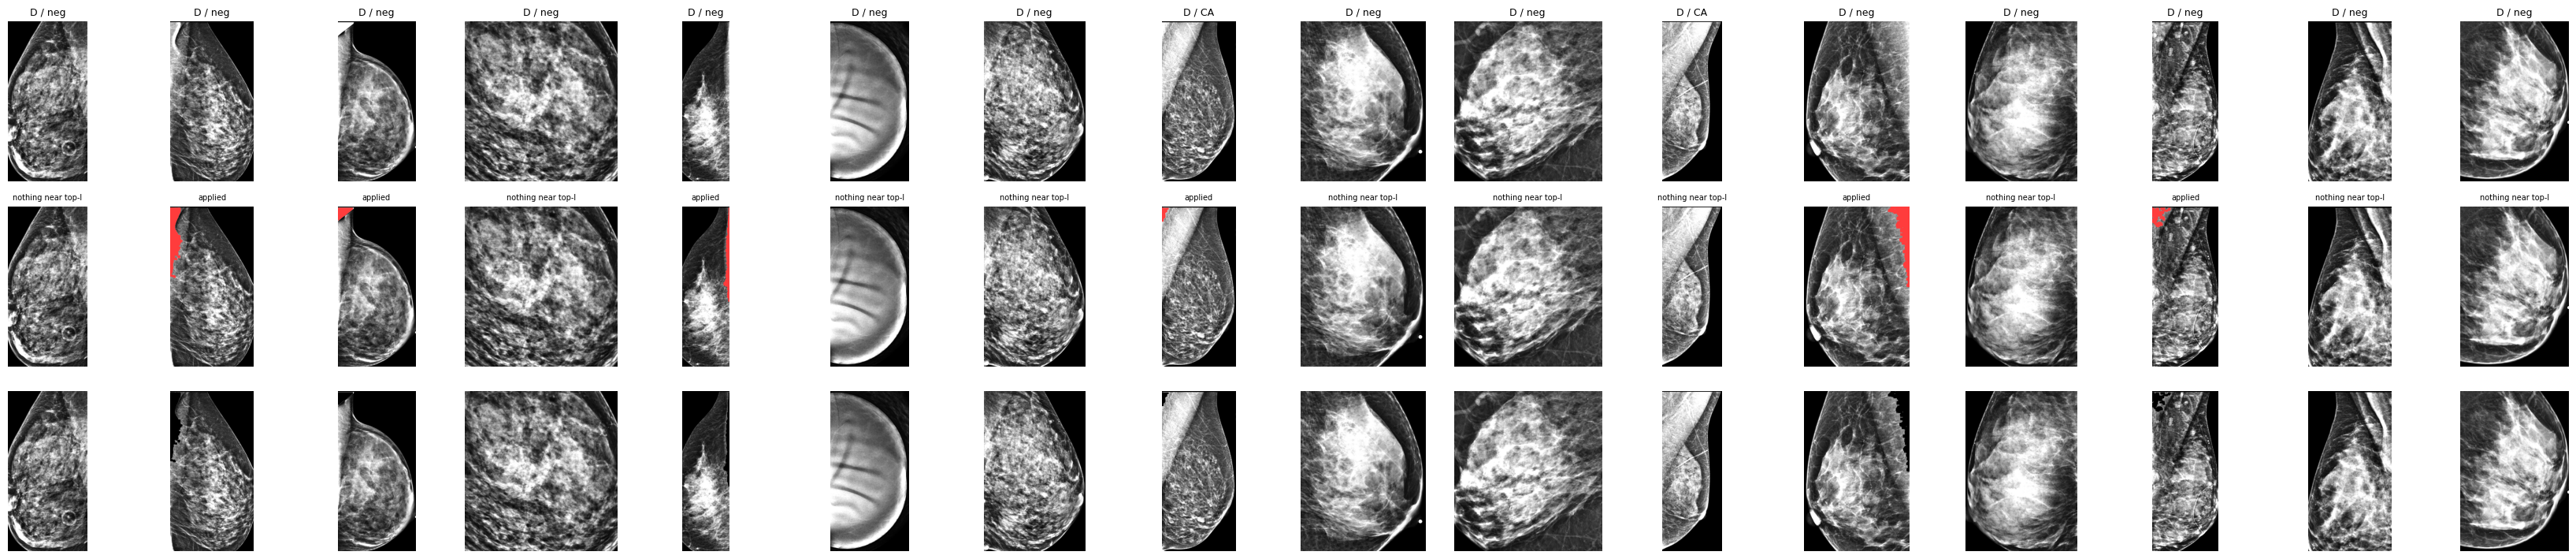

Red must cover the muscle triangle and nothing else. If it reaches into breast tissue on
any image here, the method is not usable on dense breasts and the answer is to stop.


In [28]:
dD = pick(diag[diag.density == 'D'], 16)
best_variant = 'v2 cropped first'
N = len(dD)
fig, ax = plt.subplots(3, N, figsize=(2.1 * N, 7.2))
for j in range(N):
    r = dD.iloc[j]
    raw = load_raw(r['path'])
    base = crop_breast(raw)
    out, mask, info = remove_pectoral_v2(base, return_mask=True)
    ov = np.dstack([base, base, base]).astype(np.uint8)
    ov[mask] = [255, 60, 60]
    ax[0, j].imshow(base, cmap='gray')
    ax[0, j].set_title('D / %s' % ('CA' if r.cancer else 'neg'), fontsize=9)
    ax[1, j].imshow(ov)
    ax[1, j].set_title('applied' if info['applied'] else info['reason'][:18], fontsize=7)
    ax[2, j].imshow(out, cmap='gray')
    for i in range(3):
        ax[i, j].axis('off')
plt.tight_layout(); plt.show()
print('Red must cover the muscle triangle and nothing else. If it reaches into breast tissue on')
print('any image here, the method is not usable on dense breasts and the answer is to stop.')

## 6. Density B, where the paired test got worse

`v11_dro` lost 0.0503 AUC on density B with an interval excluding zero. That is the one place
the pilot showed real harm, so those successful removals need looking at.

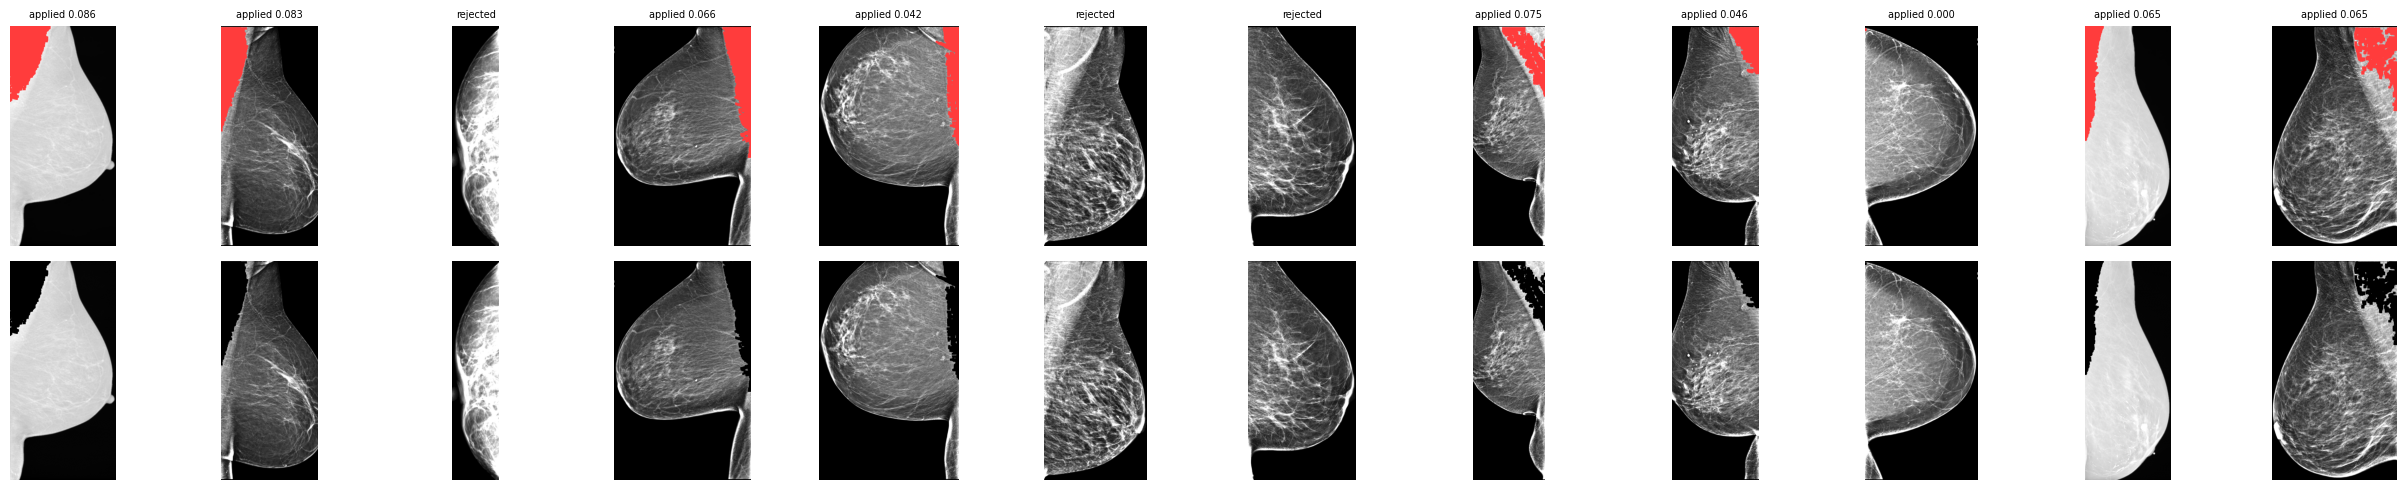

If removal is taking upper breast tissue here, that explains the density B loss and is a
reason to reject the method rather than to tune it.


In [29]:
dB = pick(diag[diag.density == 'B'], 12)
N = len(dB)
fig, ax = plt.subplots(2, N, figsize=(2.1 * N, 5.0))
for j in range(N):
    r = dB.iloc[j]
    base = crop_breast(load_raw(r['path']))
    out, mask, info = remove_pectoral_v2(base, return_mask=True)
    ov = np.dstack([base, base, base]).astype(np.uint8)
    ov[mask] = [255, 60, 60]
    ax[0, j].imshow(ov)
    ax[0, j].set_title(('applied %.3f' % info['frac_removed']) if info['applied']
                       else 'rejected', fontsize=7)
    ax[1, j].imshow(out, cmap='gray')
    for i in range(2):
        ax[i, j].axis('off')
plt.tight_layout(); plt.show()
print('If removal is taking upper breast tissue here, that explains the density B loss and is a')
print('reason to reject the method rather than to tune it.')

## 7. The gate

Only if every line reads PASS is the retry worth the GPU time.

In [30]:
sub = cmp[cmp.variant == best_variant]
mlo_rate = sub.applied.mean()
dD_rate = sub[sub.density == 'D'].applied.mean() if (sub.density == 'D').any() else float('nan')
lat_rates = sub.groupby('lat').applied.mean()
lat_gap = float(lat_rates.max() - lat_rates.min()) if len(lat_rates) == 2 else float('nan')

cc_rows = []
for _, r in pick(work[work.view == 'CC'], 60).iterrows():
    _, _, info = remove_pectoral_v2(crop_breast(load_raw(r['path'])), return_mask=True)
    cc_rows.append(info['applied'])
cc_rate = float(np.mean(cc_rows))

checks = [
    ('MLO applied >= 0.80',            mlo_rate >= 0.80, '%.3f' % mlo_rate),
    ('density D applied >= 0.80',      dD_rate >= 0.80,  '%.3f' % dD_rate),
    ('L/R gap <= 0.10',                lat_gap <= 0.10,  '%.3f' % lat_gap),
    ('CC rate well below MLO',         cc_rate < 0.5 * mlo_rate, '%.3f vs %.3f' % (cc_rate, mlo_rate)),
]
print('GATE')
for name, ok, val in checks:
    print('  %-28s %-5s  %s' % (name, 'PASS' if ok else 'FAIL', val))
print()
print('  %-28s %s' % ('masks visually correct', '[you decide from sections 5 and 6]'))
print()
if all(ok for _, ok, _ in checks):
    print('Gate passed on the automatic checks. If the images in sections 5 and 6 also look right,')
    print('swap preprocess_removed for preprocess_removed_v2 in the pilot, raise the density D')
    print('quota in the sampler, and re-run sections B through D.')
else:
    print('Gate failed. Do not re-run the paired test. Either the ordering fix was not the cause,')
    print('or the method cannot segment dense breasts. Both are reportable results, and the')
    print('sprint should move to the other candidate shifts: intensity windowing, input')
    print('resolution, and scanner-specific response.')

GATE
  MLO applied >= 0.80          PASS   0.850
  density D applied >= 0.80    PASS   1.000
  L/R gap <= 0.10              PASS   0.025
  CC rate well below MLO       FAIL   0.450 vs 0.850

  masks visually correct       [you decide from sections 5 and 6]

Gate failed. Do not re-run the paired test. Either the ordering fix was not the cause,
or the method cannot segment dense breasts. Both are reportable results, and the
sprint should move to the other candidate shifts: intensity windowing, input
resolution, and scanner-specific response.


## 8. If the gate passes

Two changes to the pilot before re-running:

1. `preprocess_removed_v2` replaces `preprocess_removed` in the `score` function
2. the sampler oversamples density D, which had 8 images last time and could never have
   supported an AUC

```python
N_MLO = 700
dD_pool = mlo_all[mlo_all.density == 'D']
extra   = dD_pool.sample(n=min(len(dD_pool), 150), random_state=SEED)
pilot   = pd.concat([pilot, extra]).drop_duplicates('image_id')
```

Report the density D count honestly whatever it comes to. RSNA has few dense-breast cancers,
and if the stratum still cannot support an interval then the pilot cannot answer the question
for the group it was built to answer it for. That is a finding, not a failure.